# Requirement 4 — Slightly Non-Stationary Multi-Campaign Bidding

**Setting:** the Requirement 2/3 instance (N campaigns, shared budget $B_{\text{total}}$, per-round
budget $\rho$, conflict graph $G$), but in a **slightly non-stationary** environment: the horizon is
partitioned into a few equal intervals; within each interval the competing-bid distribution
$m_{i,t} \sim \text{Beta}(k_i^{(j)}, 1)$ is fixed, and each interval has a different parameter vector.
Only $\Upsilon_T = 4$ change points over $T = 15000$ rounds — persistent regime shifts, in contrast
to Requirement 3's ~600 fast changes.

**Algorithms compared:**

1. **CUCB-SW** — the Requirement 2 combinatorial UCB-like bidder with a **sliding window**
   (course notebook 10, SW-UCB): statistics over the last $W$ rounds only; confidence width uses
   $\log W$.
2. **CUCB-CD** — the same bidder with a **CUSUM change detector** (notebook 10, CUSUM-UCB) per
   (campaign, bid) on the win indicator; on detection the whole campaign row is reset (all $K$ bids
   of campaign $i$ share the same $m_i$, so one detected change invalidates the entire row). Extra
   uniform exploration with probability $\alpha$ keeps the detectors fed.
3. **Primal-dual** (Requirement 3, tuned configuration) — full feedback, no forgetting mechanism;
   its guarantee is against the best *fixed* strategy.
4. **Plain CUCB** (Requirement 2 agent) — the no-forgetting control: its all-time averages go stale
   after each change.

**Benchmark:** the per-interval LP clairvoyant — in each interval, the Requirement 2 LP with that
interval's true win probabilities (the "best policy in hindsight" of notebook 10, restricted to
uniform pacing: every interval faces the same per-round budget $\rho$, the same constraint the
agents face). Secondary reference: the best **fixed** strategy in expectation (the LP on
interval-averaged win probabilities) — the gap between the two quantifies the value of tracking.

In [1]:
import sys, os, time

# Resolve repo root whether notebook is run from repo root or notebooks/
repo_root = os.path.abspath('.')
if not os.path.isdir(os.path.join(repo_root, 'src')):
    repo_root = os.path.abspath('..')
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import matplotlib.pyplot as plt

from src.core.nonstationary_env import SlightlyNonStationaryMultiCampaignEnv
from src.core.conflict_graph import ConflictGraph
from src.core.cucb_bidder import CombUCBLikeBidderAgent
from src.core.nonstationary_cucb import SWCombUCBLikeBidderAgent, CDCombUCBLikeBidderAgent
from src.core.primal_dual_bidder import PrimalDualBidderAgent
from src.core.clairvoyant import (
    win_probs_multi_campaign,
    clairvoyant_multi_campaign,
    clairvoyant_piecewise,
)
from src.utils.parallel_runner import run_trials_parallel
from src.utils.regret import summarise_regret
from src.utils.plotting import new_figure, plot_regret, save_figure

n_jobs = os.cpu_count()
print(f"Using n_jobs = {n_jobs} worker processes")

Using n_jobs = 10 worker processes


## Problem Instance

Same instance as Requirements 2 and 3 for comparability. New: 5 equal intervals of 3000 rounds.
The structure seed is chosen so that the optimal independent set changes at **every** boundary —
each change point genuinely reshuffles which campaigns are worth bidding on.

In [2]:
# --- Problem parameters (same instance as Requirements 2/3) ---
N, K, T    = 5, 20, 15000
master_seed = 42
seq_seed    = 781    # interval structure: the best IS rotates at every boundary
n_intervals = 5
Upsilon_T   = n_intervals - 1   # number of change points

values   = np.array([0.90, 0.80, 0.70, 0.85, 0.75])
bid_grid = np.linspace(0.0, 1.0, K)
edges    = [(0, 1), (2, 3)]
cg       = ConflictGraph(N, edges)

rho     = 0.40
B_total = rho * T

# --- Non-stationary hyper-parameters (notebook 10 formulas, Upsilon_T known) ---
W_theory    = int(2 * np.sqrt(T * np.log(T) / Upsilon_T))
M_cusum     = int(np.log(T / Upsilon_T))
h_cusum     = 2 * np.log(T / Upsilon_T)
alpha_cusum = np.sqrt(Upsilon_T * np.log(T / Upsilon_T) / T)

# --- Primal-dual: tuned Requirement 3 configuration ---
hedge_mult = 48
pd_kwargs = dict(
    bid_grid=bid_grid, values=values, budget=B_total, T=T, conflict_graph=cg,
    hedge_eta=hedge_mult * np.sqrt(np.log(K) / T),
    lmbd_init=0.0,
    adaptive_rho=True,
)

n_trials_cucb  = 8    # LP-based agents (one LP per feasible IS per round)
n_trials_pd    = 20   # primal-dual (cheap per round)
n_trials_sweep = 5    # sensitivity sweeps

env_kwargs = dict(values=values, T=T, sequence_seed=seq_seed, n_intervals=n_intervals)

print(f"T = {T}, rho = {rho}, B_total = {B_total:.0f}, Upsilon_T = {Upsilon_T}")
print(f"SW-UCB window        W = {W_theory}   (= 2*sqrt(T log T / Upsilon_T))")
print(f"CUSUM warm-up        M = {M_cusum}    (= log(T / Upsilon_T))")
print(f"CUSUM threshold      h = {h_cusum:.2f} (= 2 log(T / Upsilon_T))")
print(f"Extra exploration alpha = {alpha_cusum:.4f}")

T = 15000, rho = 0.4, B_total = 6000, Upsilon_T = 4
SW-UCB window        W = 379   (= 2*sqrt(T log T / Upsilon_T))
CUSUM warm-up        M = 8    (= log(T / Upsilon_T))
CUSUM threshold      h = 16.46 (= 2 log(T / Upsilon_T))
Extra exploration alpha = 0.0468


Saved → /Users/kebapcioglu/Projects/OLA project/report/figures/req4_instance.png
Interval boundaries: [0, 3000, 6000, 9000, 12000, 15000]
k_matrix (rows = intervals, cols = campaigns):
[[5 3 4 2 3]
 [1 4 1 1 2]
 [6 1 3 2 1]
 [1 5 2 5 4]
 [3 6 3 1 5]]


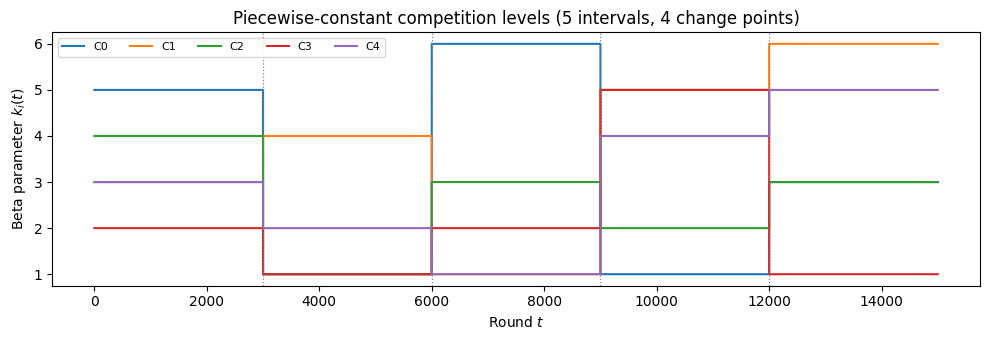

In [3]:
# Environment structure: piecewise-constant competition levels
env_ns = SlightlyNonStationaryMultiCampaignEnv(**env_kwargs)

fig, ax = plt.subplots(figsize=(10, 3.5))
for i in range(N):
    ax.step(np.arange(T), env_ns.k_seq[:, i], where='post', lw=1.5, label=f'C{i}')
for b in env_ns.boundaries[1:-1]:
    ax.axvline(b, color='grey', linestyle=':', lw=0.9)
ax.set_xlabel('Round $t$')
ax.set_ylabel('Beta parameter $k_i(t)$')
ax.set_title(f'Piecewise-constant competition levels ({n_intervals} intervals, '
             f'{Upsilon_T} change points)')
ax.legend(ncol=N, fontsize=8)
plt.tight_layout()
save_figure(fig, 'report/figures/req4_instance.png')

print(f"Interval boundaries: {env_ns.boundaries.tolist()}")
print(f"k_matrix (rows = intervals, cols = campaigns):\n{env_ns.k_matrix.astype(int)}")

## Benchmarks

**Per-interval clairvoyant** (primary): the Requirement 2 LP solved with each interval's true win
probabilities, expanded to a per-round $(T,)$ reward sequence. It paces $\rho$ uniformly — it may
not shift budget between intervals — which is the same constraint every agent faces.

**Best fixed strategy in expectation** (secondary): the same LP on interval-length-weighted average
win probabilities. This is the comparator the primal-dual method's guarantee refers to; the gap to
the per-interval clairvoyant is the maximum value any tracking algorithm can extract.

Per-interval clairvoyant:
  interval 0 (rounds     0- 3000): reward/round = 0.1666, cost/round = 0.4000, best IS = [1, 3, 4]
  interval 1 (rounds  3000- 6000): reward/round = 0.4388, cost/round = 0.4000, best IS = [0, 3, 4]
  interval 2 (rounds  6000- 9000): reward/round = 0.3876, cost/round = 0.4000, best IS = [1, 3, 4]
  interval 3 (rounds  9000-12000): reward/round = 0.2719, cost/round = 0.3957, best IS = [0, 2, 4]
  interval 4 (rounds 12000-15000): reward/round = 0.2601, cost/round = 0.4000, best IS = [0, 3, 4]

Dynamic benchmark average : 0.3050 /round
Best fixed in expectation : 0.2496 /round  (cost 0.3504)
Value of tracking         : 0.0554 /round (18.2% of the dynamic benchmark)
Saved → /Users/kebapcioglu/Projects/OLA project/report/figures/req4_benchmarks.png


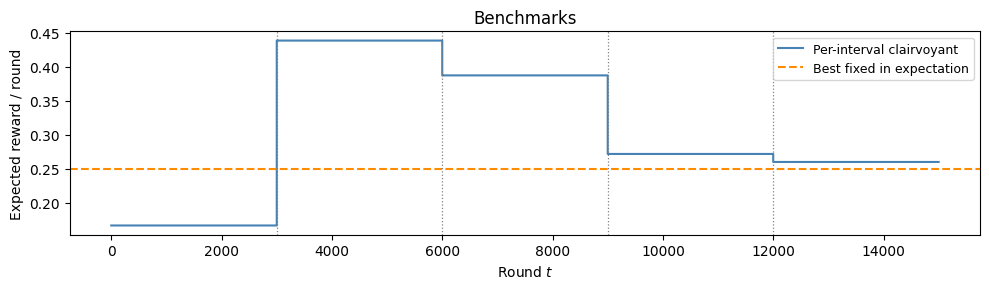

In [4]:
reward_seq, interval_info = clairvoyant_piecewise(
    bid_grid, values, rho, env_ns.k_matrix, env_ns.boundaries, cg
)

# Best fixed strategy in expectation: LP on interval-averaged win probabilities
# (valid because expected utility/cost of a fixed strategy are linear in the
# win probabilities, and intervals have equal length)
wp_avg = np.mean(
    [win_probs_multi_campaign(bid_grid, env_ns.k_matrix[j].astype(int))
     for j in range(n_intervals)],
    axis=0,
)
gamma_fixed, cv_fixed, cv_fixed_cost = clairvoyant_multi_campaign(bid_grid, values, rho, wp_avg, cg)

print("Per-interval clairvoyant:")
for j, info in enumerate(interval_info):
    print(f"  interval {j} (rounds {env_ns.boundaries[j]:>5d}-{env_ns.boundaries[j+1]:>5d}): "
          f"reward/round = {info['reward']:.4f}, cost/round = {info['cost']:.4f}, "
          f"best IS = {info['campaigns']}")
cv_dyn_avg = reward_seq.mean()
print(f"\nDynamic benchmark average : {cv_dyn_avg:.4f} /round")
print(f"Best fixed in expectation : {cv_fixed:.4f} /round  (cost {cv_fixed_cost:.4f})")
print(f"Value of tracking         : {cv_dyn_avg - cv_fixed:.4f} /round "
      f"({100 * (cv_dyn_avg - cv_fixed) / cv_dyn_avg:.1f}% of the dynamic benchmark)")

fig, ax = plt.subplots(figsize=(10, 3))
ax.step(np.arange(T), reward_seq, where='post', color='steelblue',
        label='Per-interval clairvoyant')
ax.axhline(cv_fixed, color='darkorange', linestyle='--', label='Best fixed in expectation')
for b in env_ns.boundaries[1:-1]:
    ax.axvline(b, color='grey', linestyle=':', lw=0.9)
ax.set_xlabel('Round $t$')
ax.set_ylabel('Expected reward / round')
ax.set_title('Benchmarks')
ax.legend(fontsize=9)
plt.tight_layout()
save_figure(fig, 'report/figures/req4_benchmarks.png')

## Main Comparison

All four agents on the same environment, all measured against the same per-interval clairvoyant.
Each agent runs its own independent trials (structure fixed by `seq_seed`, competing bids resampled
per trial — the notebook 10 protocol for piecewise-stationary stochastic environments).

In [5]:
agent_configs = {
    "CUCB (no forgetting)": (
        CombUCBLikeBidderAgent,
        dict(bid_grid=bid_grid, values=values, budget=B_total, T=T, conflict_graph=cg),
        n_trials_cucb,
    ),
    "CUCB-SW": (
        SWCombUCBLikeBidderAgent,
        dict(bid_grid=bid_grid, values=values, budget=B_total, T=T, conflict_graph=cg,
             W=W_theory),
        n_trials_cucb,
    ),
    "CUCB-CD": (
        CDCombUCBLikeBidderAgent,
        dict(bid_grid=bid_grid, values=values, budget=B_total, T=T, conflict_graph=cg,
             M=M_cusum, h=h_cusum, alpha=alpha_cusum),
        n_trials_cucb,
    ),
    "Primal-dual": (PrimalDualBidderAgent, pd_kwargs, n_trials_pd),
}

results = {}
for idx, (name, (agent_cls, agent_kw, n_tr)) in enumerate(agent_configs.items()):
    t0 = time.time()
    results[name] = run_trials_parallel(
        env_cls=SlightlyNonStationaryMultiCampaignEnv, env_kwargs=env_kwargs,
        agent_cls=agent_cls, agent_kwargs=agent_kw,
        T=T, n_trials=n_tr, master_seed=master_seed + idx,
        clairvoyant_reward=reward_seq, n_jobs=n_jobs,
    )
    print(f"{name:<22s} {n_tr} trials done in {time.time() - t0:5.0f}s")

CUCB (no forgetting)   8 trials done in   168s


CUCB-SW                8 trials done in   170s


CUCB-CD                8 trials done in   170s


Primal-dual            20 trials done in     3s


## Results — Cumulative Regret vs the Per-Interval Clairvoyant

Saved → /Users/kebapcioglu/Projects/OLA project/report/figures/req4_regret_main.png
agent                    final regret   % of dynamic OPT
CUCB (no forgetting)     1423.9 +/-  90.4           68.9%
CUCB-SW                  2970.2 +/-  38.5           35.1%
CUCB-CD                  2482.0 +/-  62.0           45.8%
Primal-dual               996.1 +/-  26.1           78.2%
(best fixed, exact)       831.5              81.8%


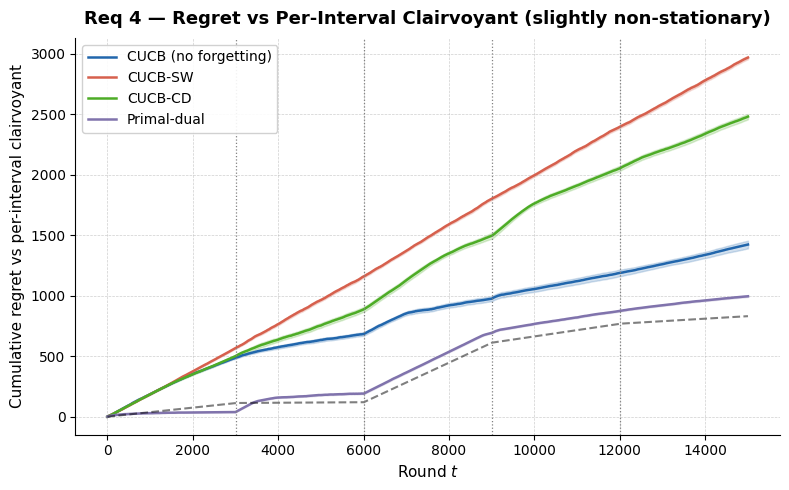

In [6]:
ts = np.arange(1, T + 1)
n_trials_of = {name: cfg[2] for name, cfg in agent_configs.items()}

fig, ax = new_figure('Req 4 — Regret vs Per-Interval Clairvoyant (slightly non-stationary)')
for name in agent_configs:
    mean_r, std_r = summarise_regret(results[name]['regret_matrix'])
    plot_regret(ax, mean_r, std_r, n_trials=n_trials_of[name], label=name)
# Reference: an agent playing the best FIXED strategy perfectly would still
# accumulate this much regret vs the dynamic benchmark (= the value of tracking).
# Its per-round reward must be evaluated per interval (conditional expectation,
# not the overall average cv_fixed) for the line to be meaningful before T;
# the interval-length-weighted mean of fixed_seq equals cv_fixed by linearity.
fixed_seq = np.zeros(T)
for j in range(n_intervals):
    wp_j = win_probs_multi_campaign(bid_grid, env_ns.k_matrix[j].astype(int))
    r_j = sum(gamma_fixed[i] @ ((values[i] - bid_grid) * wp_j[i]) for i in gamma_fixed)
    fixed_seq[env_ns.boundaries[j]:env_ns.boundaries[j + 1]] = r_j
assert np.isclose(fixed_seq.mean(), cv_fixed)
ax.plot(ts, np.cumsum(reward_seq - fixed_seq), color='black', linestyle='--', alpha=0.5,
        label='Best fixed strategy (primal-dual comparator)')
for b in env_ns.boundaries[1:-1]:
    ax.axvline(b, color='grey', linestyle=':', lw=0.9)
ax.set_ylabel('Cumulative regret vs per-interval clairvoyant')
plt.tight_layout()
save_figure(fig, 'report/figures/req4_regret_main.png')

print(f"{'agent':<22s} {'final regret':>14s} {'% of dynamic OPT':>18s}")
for name in agent_configs:
    mean_r, std_r = summarise_regret(results[name]['regret_matrix'])
    achieved = cv_dyn_avg - mean_r[-1] / T
    print(f"{name:<22s} {mean_r[-1]:8.1f} +/- {std_r[-1]:5.1f} {100 * achieved / cv_dyn_avg:14.1f}%")
print(f"{'(best fixed, exact)':<22s} {np.sum(reward_seq - cv_fixed):8.1f}          "
      f"{100 * cv_fixed / cv_dyn_avg:8.1f}%")

## Budget Consumption

Sanity check: cumulative cost must never exceed $B_{\text{total}}$ in any trial of any agent —
the CUCB variants inherit the hard per-round affordability cap, the primal-dual agent stops when
the remaining budget cannot cover a worst-case round.

CUCB (no forgetting)   max spend   5334.1 / 6000   (violated: False)
CUCB-SW                max spend   5712.5 / 6000   (violated: False)
CUCB-CD                max spend   5660.3 / 6000   (violated: False)
Primal-dual            max spend   4473.1 / 6000   (violated: False)
Saved → /Users/kebapcioglu/Projects/OLA project/report/figures/req4_budget.png


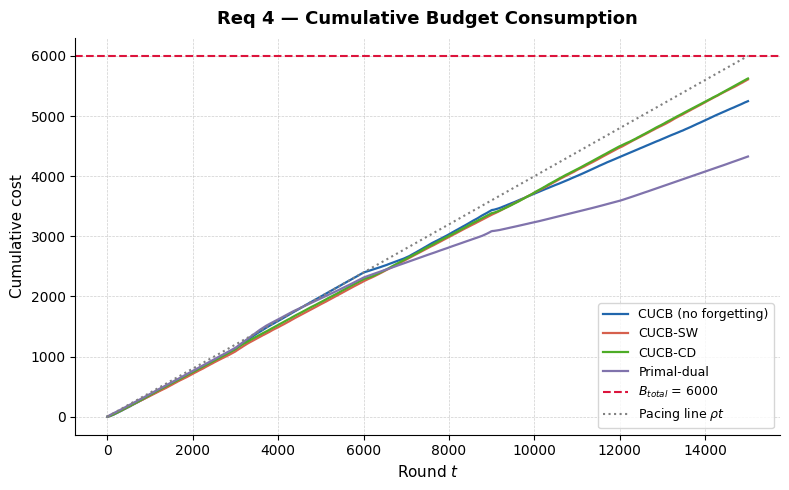

In [7]:
fig, ax = new_figure('Req 4 — Cumulative Budget Consumption')
for name in agent_configs:
    cum = np.cumsum(results[name]['cost_matrix'], axis=1)
    ax.plot(ts, cum.mean(axis=0), lw=1.6, label=name)
    max_spend = cum[:, -1].max()
    print(f"{name:<22s} max spend {max_spend:8.1f} / {B_total:.0f}   "
          f"(violated: {max_spend > B_total + 1e-6})")
ax.axhline(B_total, color='crimson', linestyle='--', label=f'$B_{{total}}$ = {B_total:.0f}')
ax.plot(ts, rho * ts, color='grey', linestyle=':', label=r'Pacing line $\rho t$')
ax.set_ylabel('Cumulative cost')
ax.legend(fontsize=9)
plt.tight_layout()
save_figure(fig, 'report/figures/req4_budget.png')

## Diagnostics — Change Detection at Work

One inspection trial of CUCB-CD: when does each campaign's detector fire relative to the true
change points? Detection cannot be instantaneous — after a change, the played arms must first
accumulate enough deviating win-indicator samples to push a CUSUM statistic past $h$.

Saved → /Users/kebapcioglu/Projects/OLA project/report/figures/req4_cd_resets.png
Resets per campaign: [13, 2, 0, 15, 10]   (total 40)
  change at t=3000: first-detection delay per detected campaign = [np.int64(17), np.int64(220), np.int64(612)]
  change at t=6000: first-detection delay per detected campaign = [np.int64(188), np.int64(322), np.int64(326), np.int64(2051)]
  change at t=9000: first-detection delay per detected campaign = [np.int64(30), np.int64(291), np.int64(722), np.int64(752)]
  change at t=12000: first-detection delay per detected campaign = [np.int64(46), np.int64(335)]
Resets more than 1000 rounds after any change point (false alarms / re-resets): 25


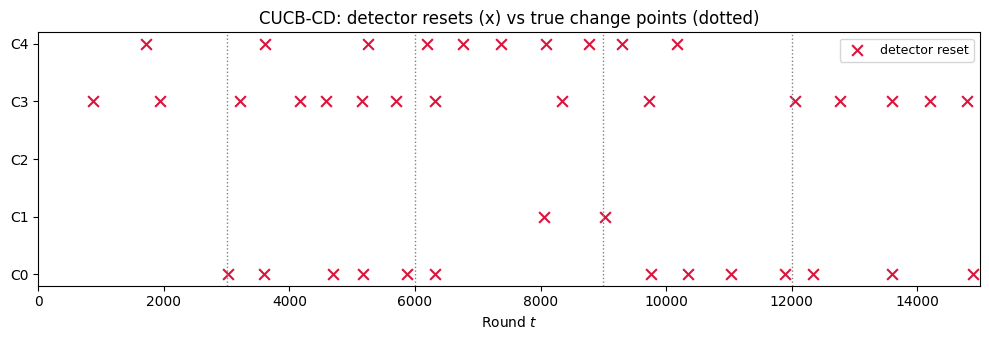

In [8]:
env_i = SlightlyNonStationaryMultiCampaignEnv(**env_kwargs)
agent_cd = CDCombUCBLikeBidderAgent(
    bid_grid=bid_grid, values=values, budget=B_total, T=T, conflict_graph=cg,
    M=M_cusum, h=h_cusum, alpha=alpha_cusum, rng=np.random.default_rng(0),
)
env_i.reset(np.random.default_rng(1))
agent_cd.reset()
for _ in range(T):
    a = agent_cd.select_action()
    fb = env_i.round(a)
    agent_cd.update(fb)

fig, ax = plt.subplots(figsize=(10, 3.5))
for i in range(N):
    resets = agent_cd.reset_history[i]
    ax.scatter(resets, [i] * len(resets), marker='x', s=60, color='crimson',
               label='detector reset' if i == 0 else None)
for b in env_ns.boundaries[1:-1]:
    ax.axvline(b, color='grey', linestyle=':', lw=1.0)
ax.set_yticks(range(N))
ax.set_yticklabels([f'C{i}' for i in range(N)])
ax.set_xlabel('Round $t$')
ax.set_xlim(0, T)
ax.set_title('CUCB-CD: detector resets (x) vs true change points (dotted)')
ax.legend(fontsize=9)
plt.tight_layout()
save_figure(fig, 'report/figures/req4_cd_resets.png')

all_resets = sorted(t for h in agent_cd.reset_history for t in h)
print(f"Resets per campaign: {agent_cd.n_resets.astype(int).tolist()}   "
      f"(total {len(all_resets)})")
change_points = env_ns.boundaries[1:-1]
for b in change_points:
    delays = [min((t - b for t in agent_cd.reset_history[i] if t >= b), default=None)
              for i in range(N)]
    delays = [d for d in delays if d is not None and d < 3000]
    print(f"  change at t={b}: first-detection delay per detected campaign = "
          f"{sorted(delays) if delays else 'none within the interval'}")
false_alarms = [t for t in all_resets
                if not any(0 <= t - b < 1000 for b in change_points)]
print(f"Resets more than 1000 rounds after any change point (false alarms / re-resets): "
      f"{len(false_alarms)}")

## Diagnostics — the Sliding Window Forgetting

One inspection trial of CUCB-SW: windowed pull counts just **before** the third change point vs
$W$ rounds **after** it. Before the change the window is concentrated on the previous regime's
best arms; after the change the old observations have been forgotten and the counts have moved.

Saved → /Users/kebapcioglu/Projects/OLA project/report/figures/req4_sw_heatmap.png


/Users/kebapcioglu/Projects/OLA project/src/utils/plotting.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


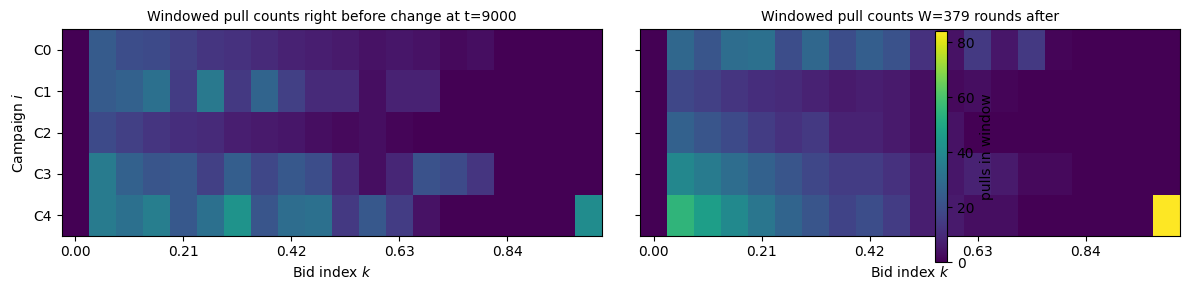

In [9]:
env_i = SlightlyNonStationaryMultiCampaignEnv(**env_kwargs)
agent_sw = SWCombUCBLikeBidderAgent(
    bid_grid=bid_grid, values=values, budget=B_total, T=T, conflict_graph=cg,
    W=W_theory, rng=np.random.default_rng(0),
)
env_i.reset(np.random.default_rng(1))
agent_sw.reset()
b3 = int(env_ns.boundaries[3])
snap_before, snap_after = None, None
for t in range(T):
    a = agent_sw.select_action()
    fb = env_i.round(a)
    agent_sw.update(fb)
    if t == b3 - 1:
        snap_before = agent_sw.n_pulls.copy()
    elif t == b3 + agent_sw.W:
        snap_after = agent_sw.n_pulls.copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
vmax = max(snap_before.max(), snap_after.max())
for ax, snap, title in [
    (axes[0], snap_before, f'right before change at t={b3}'),
    (axes[1], snap_after, f'W={agent_sw.W} rounds after'),
]:
    im = ax.imshow(snap, aspect='auto', cmap='viridis', vmin=0, vmax=vmax)
    ax.set_title(f'Windowed pull counts {title}', fontsize=10)
    ax.set_xlabel('Bid index $k$')
    ax.set_xticks(range(0, K, 4))
    ax.set_xticklabels([f'{bid_grid[k]:.2f}' for k in range(0, K, 4)])
axes[0].set_ylabel('Campaign $i$')
axes[0].set_yticks(range(N))
axes[0].set_yticklabels([f'C{i}' for i in range(N)])
plt.colorbar(im, ax=axes, label='pulls in window')
save_figure(fig, 'report/figures/req4_sw_heatmap.png')

## Sensitivity — Window Size $W$

The theory value $W^* = 2\sqrt{T \log T / \Upsilon_T}$ assumes $\Upsilon_T$ is known. Sweep
$W \in \{W^*/4,\, W^*/2,\, W^*,\, 2W^*,\, 4W^*\}$ plus $W = 3000$ (exactly one interval — the
theoretically ideal memory span) and $W = 6000$: too small = estimates stay noisy (and the
$\log W$ width shrinks), too large = stale samples survive changes longer. Plain CUCB is the
$W \to \infty$ limit.

W =    94: final regret =  3216.8 +/-  29.4   (137s)


W =   189: final regret =  3091.0 +/-  56.4   (136s)


W =   379: final regret =  2953.1 +/-  91.5   (137s)


W =   758: final regret =  2596.7 +/-  27.3   (137s)


W =  1516: final regret =  2219.5 +/-  64.3   (136s)


W =  3000: final regret =  1907.1 +/-  34.2   (137s)


W =  6000: final regret =  1658.4 +/-  92.7   (137s)
Saved → /Users/kebapcioglu/Projects/OLA project/report/figures/req4_sensitivity_W.png


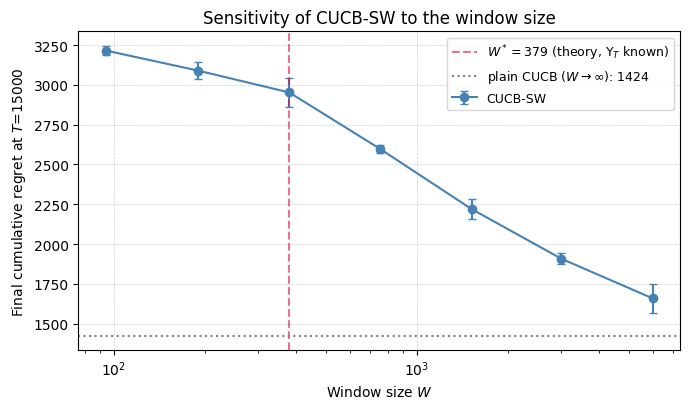

In [10]:
W_list = [W_theory // 4, W_theory // 2, W_theory, 2 * W_theory, 4 * W_theory,
          3000, 6000]  # 3000 = interval length; 6000 = 2 intervals
sw_sweep = []
for W_ in W_list:
    t0 = time.time()
    res = run_trials_parallel(
        env_cls=SlightlyNonStationaryMultiCampaignEnv, env_kwargs=env_kwargs,
        agent_cls=SWCombUCBLikeBidderAgent,
        agent_kwargs=dict(bid_grid=bid_grid, values=values, budget=B_total, T=T,
                          conflict_graph=cg, W=W_),
        T=T, n_trials=n_trials_sweep, master_seed=master_seed + 10,
        clairvoyant_reward=reward_seq, n_jobs=n_jobs,
    )
    reg = res['regret_matrix'][:, -1]
    sw_sweep.append((reg.mean(), reg.std()))
    print(f"W = {W_:>5d}: final regret = {reg.mean():7.1f} +/- {reg.std():5.1f}   "
          f"({time.time() - t0:.0f}s)")

cucb_ref = summarise_regret(results['CUCB (no forgetting)']['regret_matrix'])[0][-1]
fig, ax = plt.subplots(figsize=(7, 4.2))
means = np.array([m for m, _ in sw_sweep])
stds = np.array([s for _, s in sw_sweep])
ax.errorbar(W_list, means, yerr=stds, fmt='o-', color='steelblue', capsize=3,
            label='CUCB-SW')
ax.axvline(W_theory, color='crimson', linestyle='--', alpha=0.6,
           label=f'$W^* = {W_theory}$ (theory, $\\Upsilon_T$ known)')
ax.axhline(cucb_ref, color='grey', linestyle=':',
           label=f'plain CUCB ($W \\to \\infty$): {cucb_ref:.0f}')
ax.set_xscale('log')
ax.set_xlabel('Window size $W$')
ax.set_ylabel(f'Final cumulative regret at $T$={T}')
ax.set_title('Sensitivity of CUCB-SW to the window size')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()
save_figure(fig, 'report/figures/req4_sensitivity_W.png')

## Sensitivity — CUSUM Threshold $h$ and Warm-Up $M$

Sweep a grid around the notebook 10 defaults $h^* = 2\log(T/\Upsilon_T)$, $M^* =
\lfloor \log(T/\Upsilon_T) \rfloor$. Small $h$ = trigger-happy (false alarms discard good
statistics), large $h$ = sluggish detection; $M$ trades baseline accuracy against detection
readiness.

h =  8.23, M =  4: final regret =  2564.0 +/- 108.3   (137s)


h =  8.23, M =  8: final regret =  2560.8 +/- 113.3   (136s)


h =  8.23, M = 32: final regret =  2452.9 +/- 140.9   (138s)


h = 16.46, M =  4: final regret =  2484.0 +/-  99.7   (137s)


h = 16.46, M =  8: final regret =  2499.1 +/-  57.8   (137s)


h = 16.46, M = 32: final regret =  2387.4 +/-  80.0   (137s)


h = 32.92, M =  4: final regret =  2382.3 +/-  80.2   (138s)


h = 32.92, M =  8: final regret =  2408.3 +/-  86.9   (137s)


h = 32.92, M = 32: final regret =  2374.5 +/-  40.9   (138s)
Saved → /Users/kebapcioglu/Projects/OLA project/report/figures/req4_sensitivity_hM.png


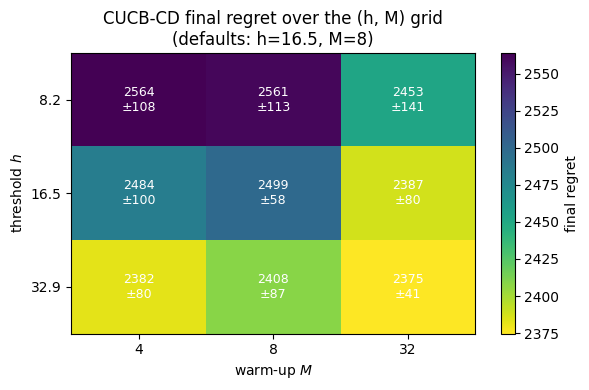

In [11]:
h_list = [0.5 * h_cusum, h_cusum, 2.0 * h_cusum]
M_list = [max(2, M_cusum // 2), M_cusum, 4 * M_cusum]
grid = np.zeros((len(h_list), len(M_list)))
grid_std = np.zeros_like(grid)
for a, h_ in enumerate(h_list):
    for b, M_ in enumerate(M_list):
        t0 = time.time()
        res = run_trials_parallel(
            env_cls=SlightlyNonStationaryMultiCampaignEnv, env_kwargs=env_kwargs,
            agent_cls=CDCombUCBLikeBidderAgent,
            agent_kwargs=dict(bid_grid=bid_grid, values=values, budget=B_total, T=T,
                              conflict_graph=cg, M=M_, h=h_, alpha=alpha_cusum),
            T=T, n_trials=n_trials_sweep, master_seed=master_seed + 20,
            clairvoyant_reward=reward_seq, n_jobs=n_jobs,
        )
        reg = res['regret_matrix'][:, -1]
        grid[a, b] = reg.mean()
        grid_std[a, b] = reg.std()
        print(f"h = {h_:5.2f}, M = {M_:>2d}: final regret = {reg.mean():7.1f} "
              f"+/- {reg.std():5.1f}   ({time.time() - t0:.0f}s)")

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(grid, cmap='viridis_r', aspect='auto')
ax.set_xticks(range(len(M_list)))
ax.set_xticklabels([str(m) for m in M_list])
ax.set_yticks(range(len(h_list)))
ax.set_yticklabels([f'{h_:.1f}' for h_ in h_list])
ax.set_xlabel('warm-up $M$')
ax.set_ylabel('threshold $h$')
for a in range(len(h_list)):
    for b in range(len(M_list)):
        ax.text(b, a, f'{grid[a, b]:.0f}\n±{grid_std[a, b]:.0f}',
                ha='center', va='center', color='white', fontsize=9)
ax.set_title('CUCB-CD final regret over the (h, M) grid\n'
             f'(defaults: h={h_cusum:.1f}, M={M_cusum})')
plt.colorbar(im, ax=ax, label='final regret')
plt.tight_layout()
save_figure(fig, 'report/figures/req4_sensitivity_hM.png')

## Discussion

**Headline result — the expected ranking is inverted.** On this instance the two forgetting
variants are the *worst* performers, and the two methods with no adaptation mechanism are the
best:

| agent | final regret vs per-interval clairvoyant | % of dynamic OPT |
|---|---|---|
| best fixed strategy (exact) | 831 | 81.8% |
| Primal-dual (full feedback) | 996 ± 26 | 78.2% |
| CUCB (no forgetting) | 1424 ± 90 | 68.9% |
| CUCB-CD | 2482 ± 62 | 45.8% |
| CUCB-SW | 2970 ± 39 | 35.1% |

Nobody captures the tracking premium (the dynamic benchmark is 18.2% above the best fixed
strategy); the algorithms designed to capture it pay more in re-exploration than they recover in
adaptivity. We report this openly rather than adjusting the instance until the textbook ranking
appears.

**Why forgetting is expensive here — the combinatorial sample budget.** There are $N \times K =
100$ (campaign, bid) arms but semi-bandit feedback delivers at most $|S| = 3$ observations per
round. A window of $W^* = 379$ rounds therefore holds at most ~1,140 arm-observations — about 11
per arm — so the windowed confidence width $\sqrt{2\log W / n}$ stays of order 1, as large as the
whole payoff scale: windowed estimates never concentrate and the agent lives in near-permanent
exploration. Notebook 10's $W^*$ formula was calibrated on a $K = 3$, one-pull-per-round bandit,
where the same window gives >100 samples per arm. On top of that, every arm that slides out of
the window regains the optimistic-initialization bonus and the LP dutifully re-explores it — and
in first-price bidding exploration is costly (utility ≈ 0 even on a win near the value, while the
cost is real).

**The W sweep confirms this monotonically.** Final regret falls with every increase of the
window — 94 → 3217, 189 → 3091, 379 → 2953, 758 → 2597, 1516 → 2220, 3000 → 1907, 6000 → 1658 —
and the $W \to \infty$ limit (plain CUCB, 1424) is the best of the whole family. Even $W = 3000$,
exactly one interval and the theoretically ideal memory span, loses: at steady state the sliding
window keeps paying the re-exploration tax on every slide, while plain CUCB's staleness cost is
bounded — its all-time means converge to length-weighted averages across regimes, the same
self-averaging that protected it against ~600 fast changes in Requirement 3.

**CUCB-CD fails through false alarms, not missed detections.** Changes on campaigns that are
actually being played are detected quickly (first-detection delays mostly 20–750 rounds; one
outlier at 2051). But the inspection trial fired **40 resets against 4 true change points**, ~25
of them spurious (>1000 rounds after any change). The mechanism: the CUSUM baseline $u_0$ is
estimated from only $M = 8$ Bernoulli samples, so an estimation error $\varepsilon$ makes one of
the CUSUM statistics drift at rate $\varepsilon$ per sample and eventually cross $h$ — a
slow-motion false alarm that throws away a campaign's entire 20-arm row of statistics. The
$(h, M)$ grid points the same way as the W sweep: regret improves monotonically toward the most
conservative corner ($2h^*, 4M^*$ → 2375), i.e. toward plain CUCB. Campaign 2 also exposes the
semi-bandit blind spot: it is rarely part of the chosen independent set, its detectors starve,
and its changes are never detected (0 resets).

**Primal-dual wins, with a caveat.** At 996 ± 26 it essentially sits on the best-fixed frontier
(831), consistent with its no-regret guarantee against fixed strategies — and it achieves this
with zero exploration cost, because it receives **full feedback** (all $N \times K$ counterfactual
outcomes every round) while the CUCB variants must buy every observation with a bid. The
comparison therefore conflates feedback model with algorithm; the CUCB-vs-primal-dual gap should
be read with that in mind (same caveat as Requirement 3).

**Budget safety.** Never violated in any trial of any agent (max spend 5713 / 6000): the CUCB
variants inherit the hard per-round affordability cap, the primal-dual agent its worst-case
stopping rule.

**Takeaway.** "Slightly non-stationary" is precisely the regime where forgetting has to justify
itself: with $\Upsilon_T = 4$ persistent shifts, the price of re-learning 100 arms (sliding
window) or of noisy detectors (CUSUM) exceeds the staleness it removes — the opposite of notebook
10's small-$K$ setting, where the identical formulas make SW/CD clearly beneficial. In a
combinatorial semi-bandit, adaptation must be much cheaper — e.g. full feedback, which the
primal-dual method gets by assumption — before tracking the per-interval optimum becomes
profitable.